In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/687486f1cb.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/93fb82b04b.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/7d7f6c9750.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/0de750893f.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/2fecd5e844.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/514cd025fa.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/44931701fe.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/138f5c986e.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/9977af1a6f.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/0f72117666.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/beetle/5dfc1af2a8.jpg
/kaggle/input/datasets/codemasterminds01/animalsimages/animals/be

# STEP 1 — Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pickle

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

2026-04-18 09:59:40.786734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776506381.278469      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776506381.379924      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776506382.402912      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776506382.402963      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776506382.402967      55 computation_placer.cc:177] computation placer alr

# STEP 2 — Dataset Path

(Adjust if dataset name differs)

In [3]:
dataset_path = "/kaggle/input/datasets/codemasterminds01/animalsimages/animals/animals"

# STEP 3 — Image Augmentation (Important)

Prevents overfitting and improves accuracy.

In [4]:
datagen = ImageDataGenerator(

    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True

)

# STEP 4 — Load Training Dataset

In [5]:
train_data = datagen.flow_from_directory(

    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"

)

Found 4320 images belonging to 90 classes.


# STEP 5 — Load Validation Dataset

Example output:  Found 4320 images belonging to 90 classes

In [6]:
val_data = datagen.flow_from_directory(

    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"

)

Found 1080 images belonging to 90 classes.


# STEP 6 — Load MobileNetV2 Pretrained Model

This step gives huge accuracy improvement.

In [7]:
base_model = MobileNetV2(

    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"

)

I0000 00:00:1776506422.780013      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776506422.786508      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze pretrained layers: 

In [8]:
for layer in base_model.layers:
    layer.trainable = False

# STEP 7 — Add Custom Classification Layers

In [9]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation="softmax")(x)

Create final model:

In [10]:
model = Model(inputs=base_model.input, outputs=predictions)

# STEP 8 — Compile Model

In [11]:
model.compile(

    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]

)

# STEP 9 — Add EarlyStopping

Stops training automatically when validation stops improving.

In [12]:
early_stop = EarlyStopping(

    monitor="val_loss",
    patience=5,
    restore_best_weights=True

)

# STEP 10 — Train Model (High Accuracy Step)

Expected result:  Validation Accuracy ≈ 80% – 95%

In [13]:
history = model.fit(

    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]

)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1776506434.215729     138 service.cc:152] XLA service 0x7982a41118d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776506434.215770     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776506434.215775     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776506435.579461     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 10:00:46.563896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:00:46.701451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776506449.389290     138 device_co

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.0693 - loss: 4.3004

2026-04-18 10:03:15.861735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:03:15.999005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


135/135 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.0699 - loss: 4.2972 - val_accuracy: 0.5481 - val_loss: 2.4567
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 102s 755ms/step - accuracy: 0.4014 - loss: 2.5123 - val_accuracy: 0.7102 - val_loss: 1.3642
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 99s 737ms/step - accuracy: 0.5669 - loss: 1.6889 - val_accuracy: 0.7231 - val_loss: 1.1514
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 98s 729ms/step - accuracy: 0.6112 - loss: 1.4524 - val_accuracy: 0.7481 - val_loss: 1.0061
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 98s 729ms/step - accuracy: 0.6552 - loss: 1.2571 - val_accuracy: 0.7602 - val_loss: 0.9310
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 100s 744ms/step - accuracy: 0.6772 - loss: 1.1504 - val_accuracy: 0.7509 - val_loss: 0.9231
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 99s 737ms/step - accuracy: 0.7029 - loss: 1.0571 - val_accuracy: 0.7648 - val_loss: 0.8909
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 101s 751ms/step - accuracy: 0.7146 - loss: 0.9599 - va

# STEP 11 — Plot Accuracy Graph

Correct learning curve:  

Train ↑

Validation ↑

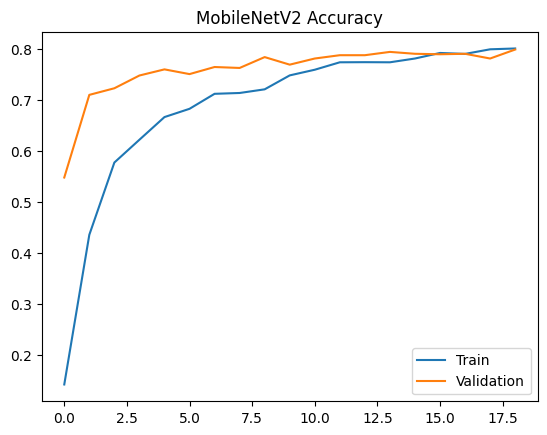

In [14]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("MobileNetV2 Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# STEP 12 — Save Trained Model

Creates deployment file:

In [15]:
model.save("animal_mobilenet_model.keras")

# STEP 13 — Save Labels File

Very important for prediction mapping.

Files created:

animal_mobilenet_model.keras

labels.pkl

In [16]:
labels = train_data.class_indices

pickle.dump(labels, open("labels.pkl","wb"))